In [1]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent

sys.path.insert(
    0,
    str(PROJECT_ROOT),
)

In [5]:
record_path = Path("../data/raw/ltafdb/00")

record = wfdb.rdrecord(str(record_path))
ann = wfdb.rdann(str(record_path), "atr")

signal = record.p_signal

signal.shape

(9661440, 2)

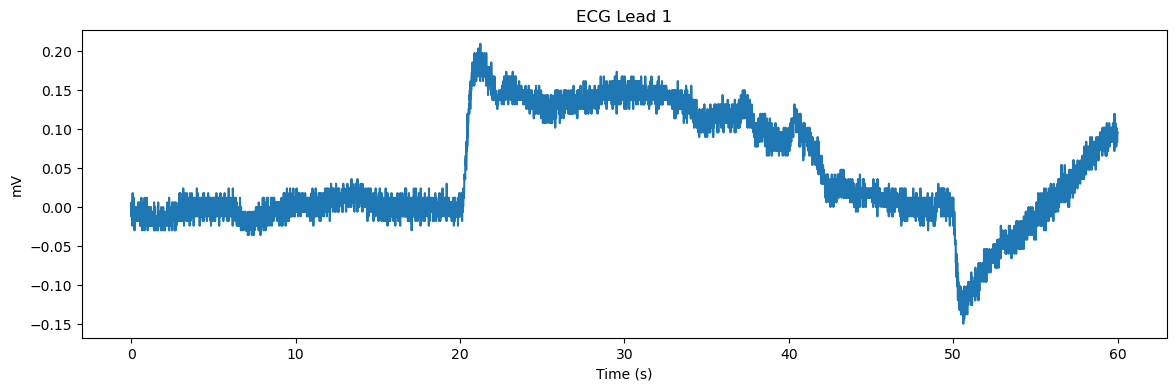

In [6]:
fs = record.fs

seconds = 60

n = int(fs * seconds)

t = np.arange(n) / fs

plt.figure(figsize=(14,4))

plt.plot(
    t,
    signal[:n,0],
)

plt.xlabel("Time (s)")
plt.ylabel("mV")
plt.title("ECG Lead 1")

plt.show()

In [7]:
for rec in ["00", "01", "03"]:

    ann = wfdb.rdann(
        f"../data/raw/ltafdb/{rec}",
        "atr",
    )

    rhythms = []

    for note in ann.aux_note:

        note = note.strip()

        if note:
            rhythms.append(note)

    print(rec)
    print(set(rhythms))
    print()

00
{'(AFIB', '(VT', '\x01 Aux', '(N'}

01
{'(SBR', '(AFIB', '\x01 Aux', '(N', '(B', 'PSE', '(AB', 'MISSB', '(T', '(SVTA'}

03
{'(SBR', '(AFIB', '\x01 Aux', '(N', '(B', '(AB', 'MISSB', '(T', '(SVTA', '(VT'}



In [8]:
from scripts.preprocess import build_label_array

labels = build_label_array(
    signal.shape[0],
    ann,
)

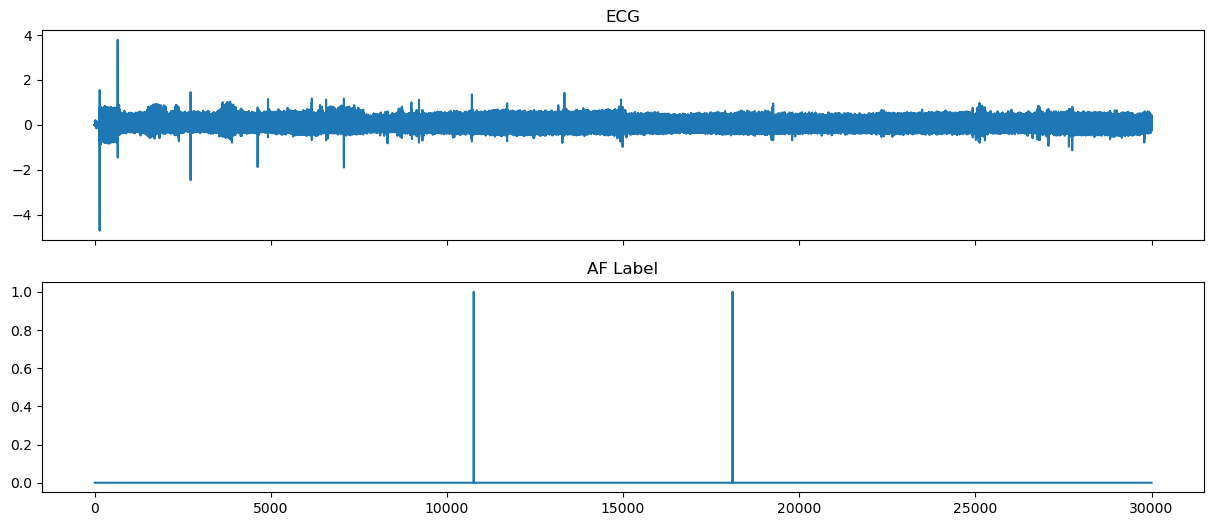

In [9]:
seconds = 30000

n = seconds * fs

t = np.arange(n) / fs

fig, ax = plt.subplots(
    2,
    1,
    figsize=(15,6),
    sharex=True,
)

ax[0].plot(
    t,
    signal[:n,0],
)

ax[0].set_title("ECG")

ax[1].plot(
    t,
    labels[:n],
)

ax[1].set_title("AF Label")

plt.show()

In [10]:
data_dir = Path("../data/processed")

files = sorted(data_dir.glob("*.npz"))

len(files)

3

In [11]:
file = files[0]

print(file)

../data/processed/00.npz


In [12]:
data = np.load(file)

list(data.keys())
data['y'][:10]
data['X'][0]

array([[-0.00599   ,  0.01734004],
       [-0.01197999,  0.02312005],
       [ 0.00599   ,  0.01734004],
       ...,
       [-0.00599   ,  0.02890006],
       [ 0.        ,  0.03468008],
       [ 0.01197999,  0.02890006]], dtype=float32)

In [13]:
X = data["X"]
y = data["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7547, 1280, 2)
y shape: (7547,)


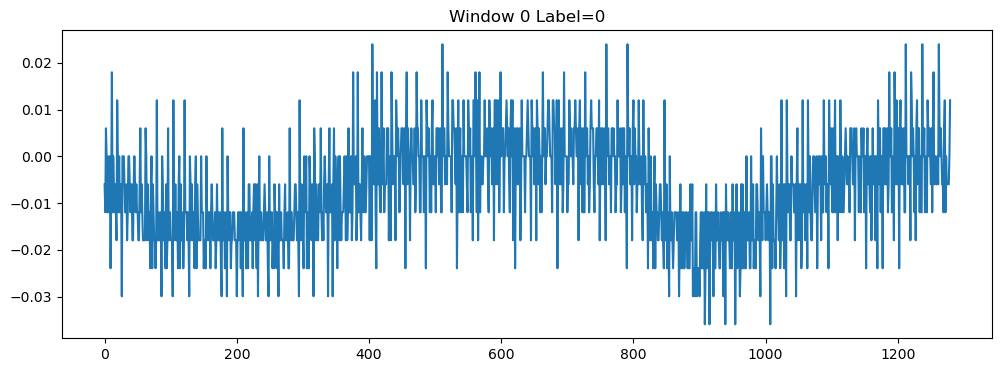

In [14]:
idx = 0

plt.figure(figsize=(12,4))

plt.plot(
    X[idx,:,0]
)

plt.title(
    f"Window {idx} Label={y[idx]}"
)

plt.show()

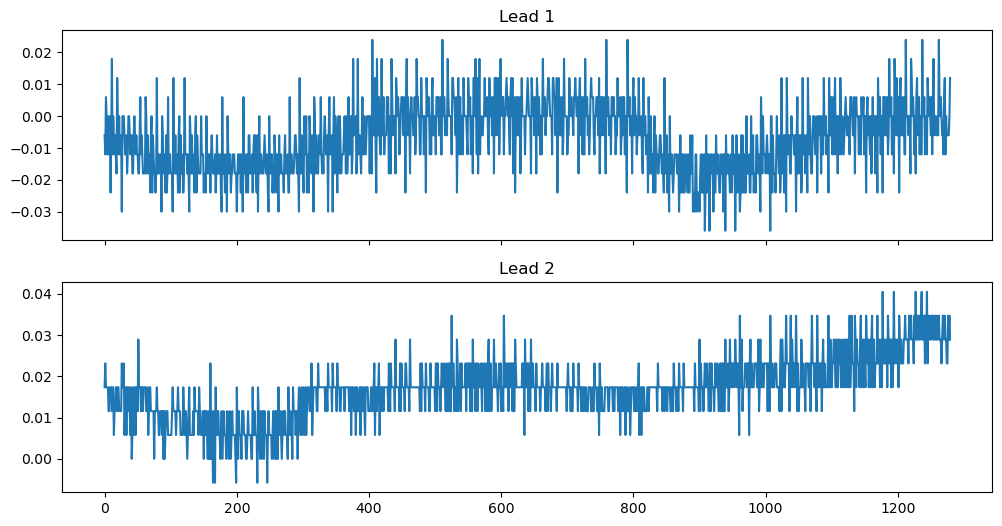

In [15]:
idx = 0

fig, ax = plt.subplots(
    2,
    1,
    figsize=(12,6),
    sharex=True,
)

ax[0].plot(X[idx,:,0])
ax[0].set_title("Lead 1")

ax[1].plot(X[idx,:,1])
ax[1].set_title("Lead 2")

plt.show()

In [16]:
all_labels = []

for file in files:

    data = np.load(file)

    all_labels.append(
        data["y"]
    )

all_labels = np.concatenate(
    all_labels
)

len(all_labels)

23685

In [17]:
pd.Series(
    all_labels
).value_counts()

0    20172
1     3513
Name: count, dtype: int64

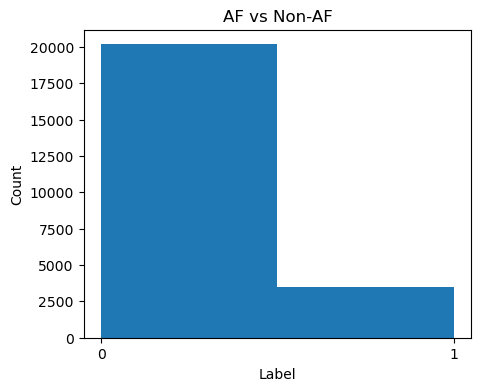

In [18]:
plt.figure(figsize=(5,4))

plt.hist(
    all_labels,
    bins=2,
)

plt.xticks([0,1])

plt.xlabel("Label")
plt.ylabel("Count")

plt.title(
    "AF vs Non-AF"
)

plt.show()

In [19]:
af_window = None

for file in files:

    data = np.load(file)

    X = data["X"]
    y = data["y"]

    matches = np.where(y == 1)[0]

    if len(matches):

        af_window = X[matches[0]]
        break

In [20]:
normal_window = None

for file in files:

    data = np.load(file)

    X = data["X"]
    y = data["y"]

    matches = np.where(y == 0)[0]

    if len(matches):

        normal_window = X[matches[0]]
        break

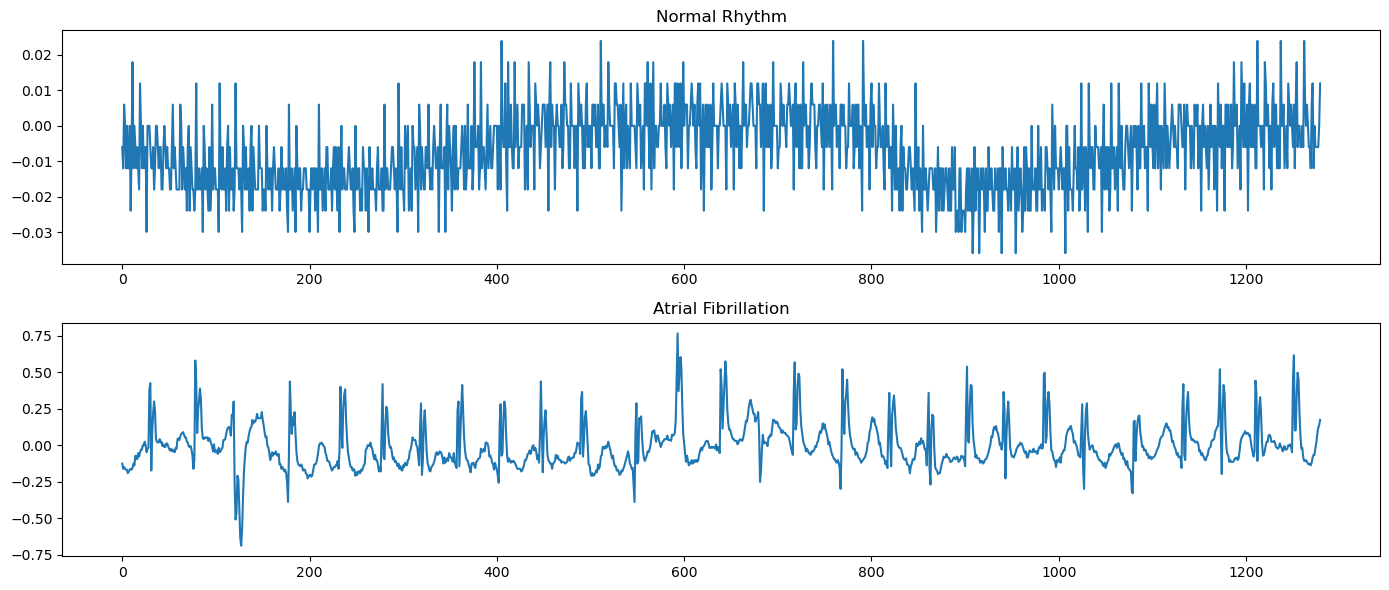

In [21]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(14,6),
)

ax[0].plot(
    normal_window[:,0]
)

ax[0].set_title(
    "Normal Rhythm"
)

ax[1].plot(
    af_window[:,0]
)

ax[1].set_title(
    "Atrial Fibrillation"
)

plt.tight_layout()

plt.show()

In [22]:
n_files = len(files)

n_windows = 0

for file in files:

    data = np.load(file)

    n_windows += len(
        data["y"]
    )

print(
    f"Files: {n_files}"
)

print(
    f"Windows: {n_windows}"
)

print(
    f"AF fraction: "
    f"{all_labels.mean():.3f}"
)

Files: 3
Windows: 23685
AF fraction: 0.148


In [23]:
for file in files:

    data = np.load(file)

    print(
        file.name,
        data["X"].shape,
        data["y"].shape,
    )

00.npz (7547, 1280, 2) (7547,)
01.npz (7403, 1280, 2) (7403,)
03.npz (8735, 1280, 2) (8735,)


In [52]:
from collections import Counter

record = wfdb.rdrecord("../data/raw/ltafdb/00")
ann = wfdb.rdann("../data/raw/ltafdb/00", "atr")

Counter(
    note.strip()
    for note in ann.aux_note
)

Counter({'': 106247, '(AFIB': 44, '(VT': 40, '(N': 5, '\x01 Aux': 1})

In [1]:


import sys
from pathlib import Path

project_root = Path.cwd()
while not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.plot_resources import plot_resources

    from src.plot_benchmark import plot_all


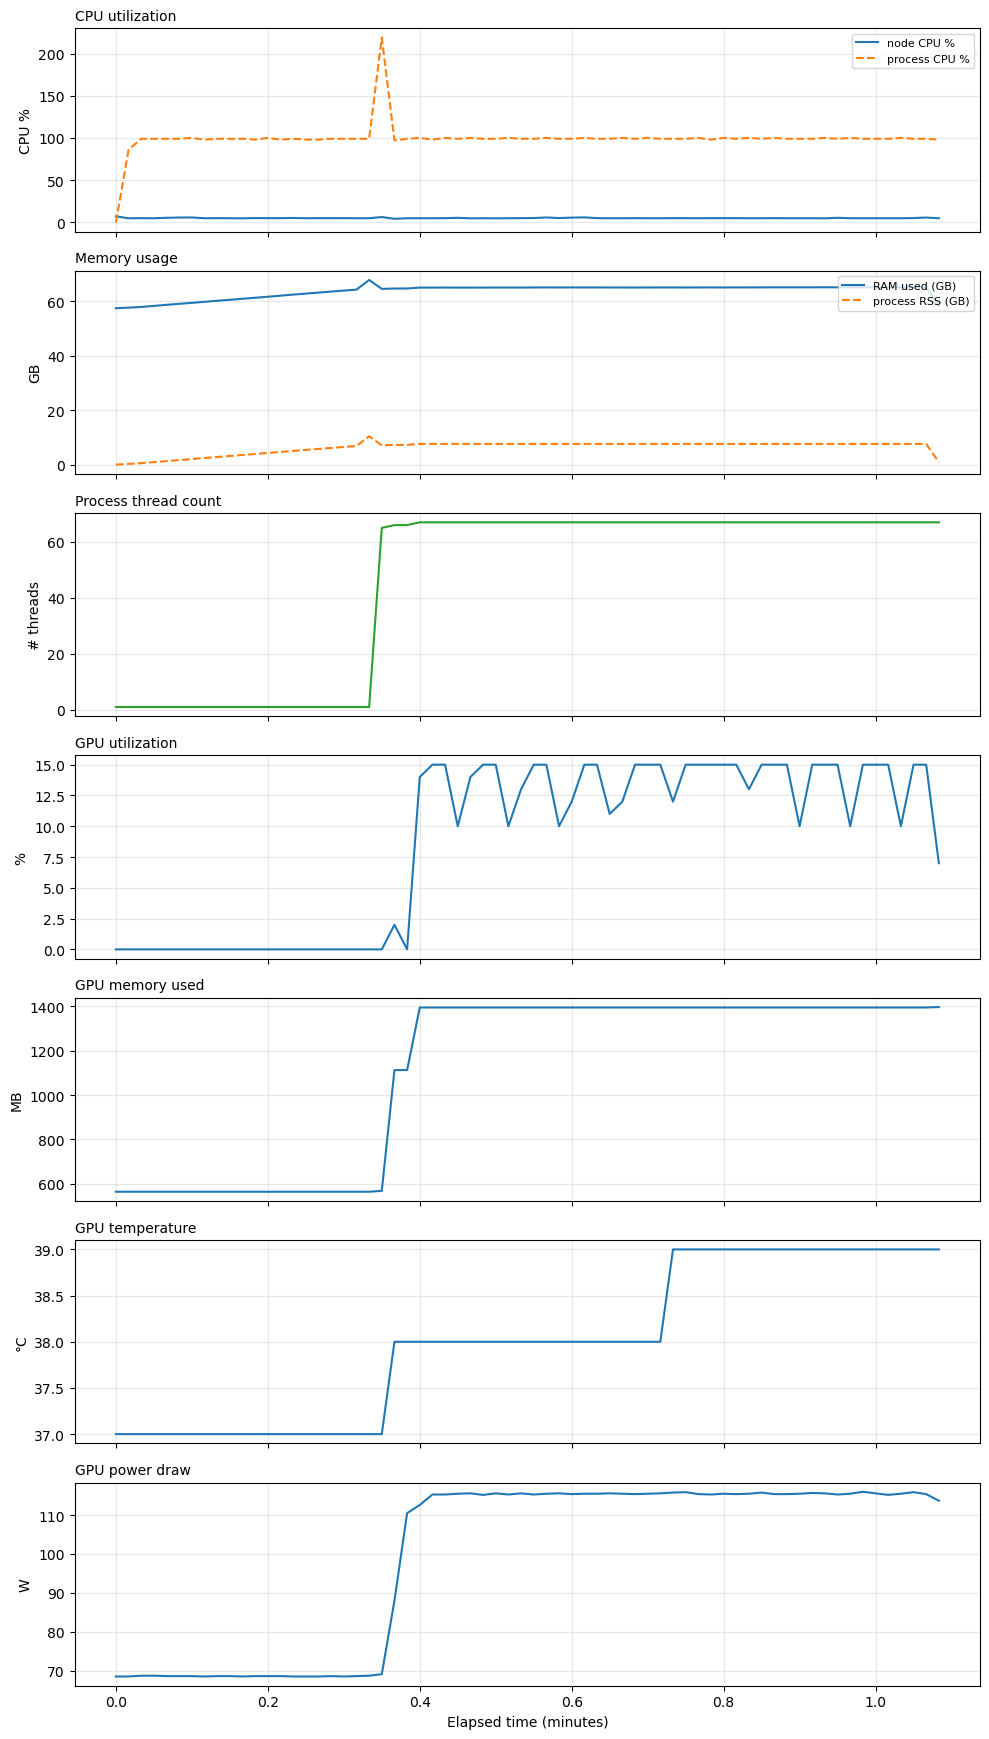

In [2]:

fig = plot_resources("../slurm/train_MLP_gpu_h100.csv")

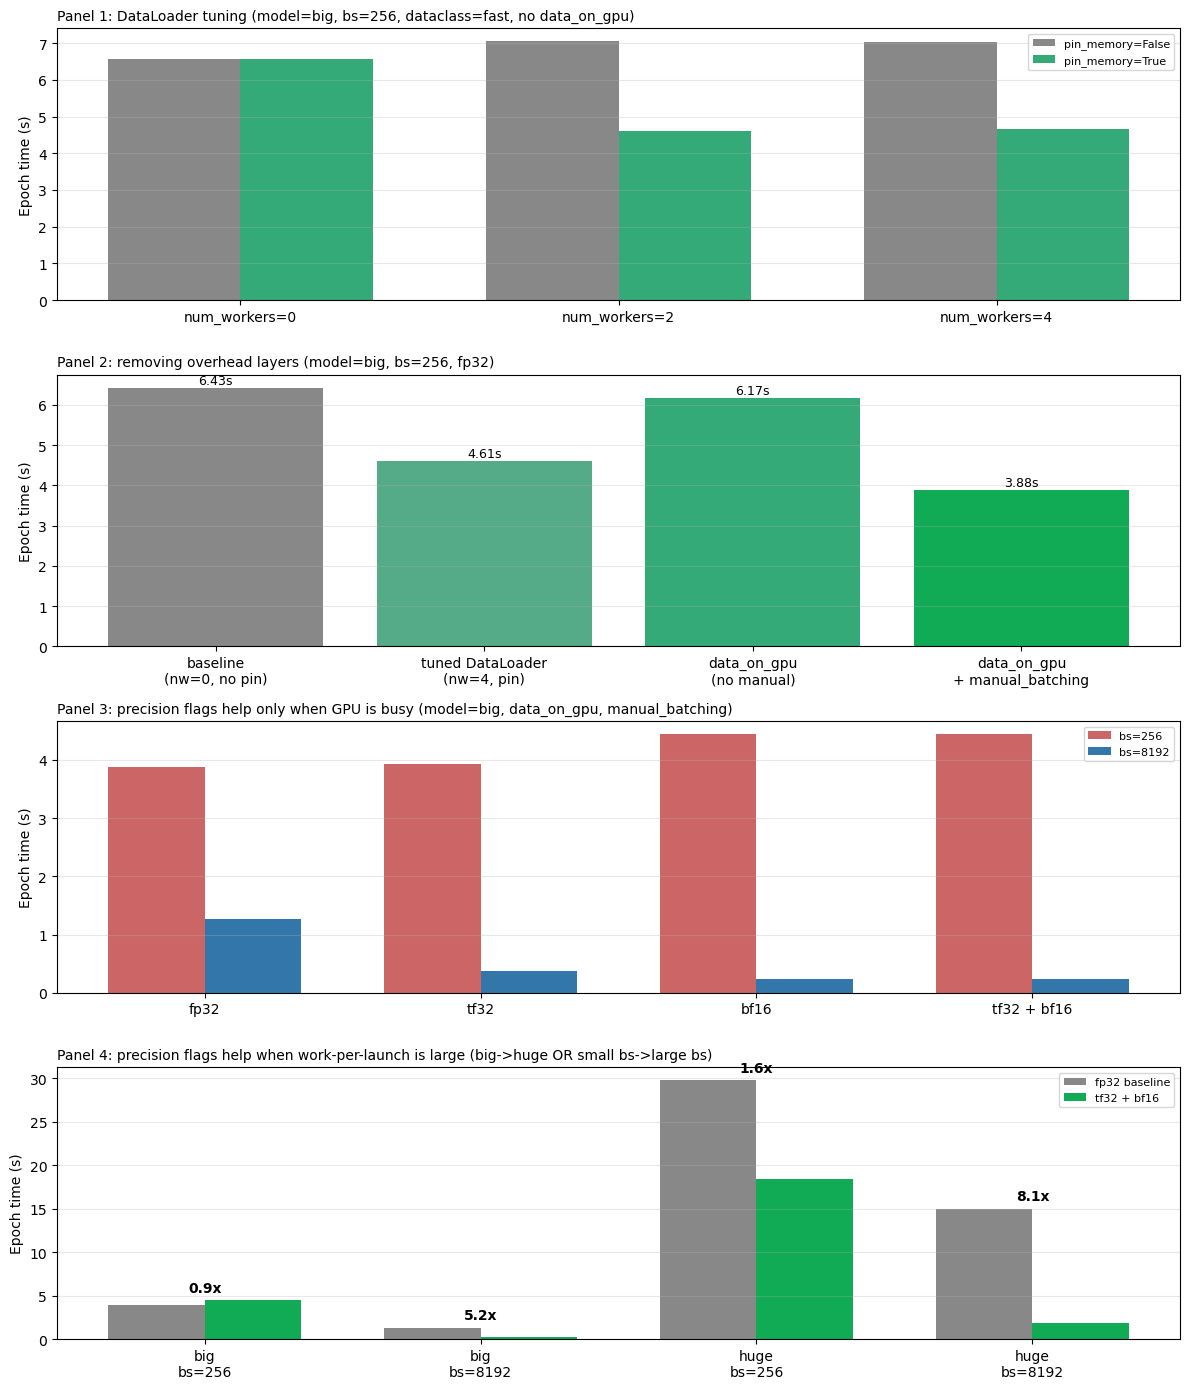

In [3]:
fig = plot_all("../slurm/benchmark_combined.csv")   # path relative to your notebook

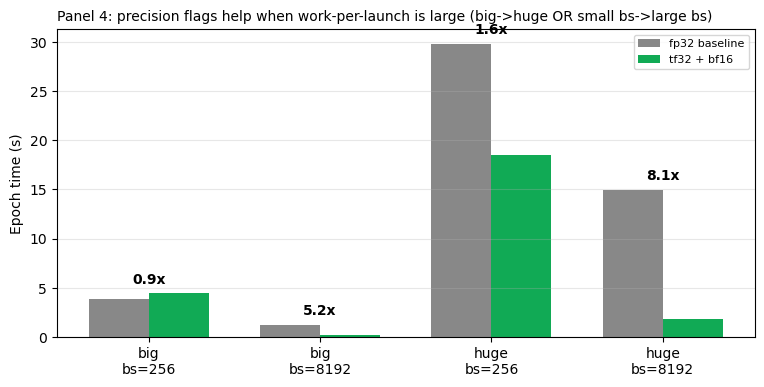

In [4]:
from src.plot_benchmark import load_benchmark, plot_amdahl_comparison
df = load_benchmark("../slurm/benchmark_combined.csv")
fig = plot_amdahl_comparison(df)
fig.savefig("amdahl_punchline.png", dpi=150, bbox_inches="tight")

In [3]:
import sys
from pathlib import Path

# Same project-root pattern as your other notebooks
project_root = Path.cwd()
while not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

from src.plot_scaling import load_results, plot_all_scaling, summary_table

# Adjust path to wherever your CSVs live -- one path or many
from pathlib import Path
results_dir = Path("../slurm/results")
csv_files = sorted(results_dir.glob("resnet1d_*.csv"))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  {f.name}")

df = load_results(*csv_files)
summary_table(df)

# Or if you've combined them with `cat`:
# df = load_results("../benchmark_combined_h100.csv")

# Quick numeric summary
summary_table(df)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Found 4 CSV files:
  resnet1d_large_n1.csv
  resnet1d_large_n2.csv
  resnet1d_medium_n2.csv
  resnet1d_medium_n4.csv


,config,world_size,epoch_time_s,speedup,efficiency_%,accuracy
0,"ResNet1d (bw=64, d=4)",2,13.53,NaN,NaN,0.9502
1,"ResNet1d (bw=64, d=4)",4,7.07,NaN,NaN,0.9504
2,"ResNet1d (bw=128, d=4)",1,43.53,1.00,100.0,0.7546
3,"ResNet1d (bw=128, d=4)",2,22.14,1.97,98.3,0.9454


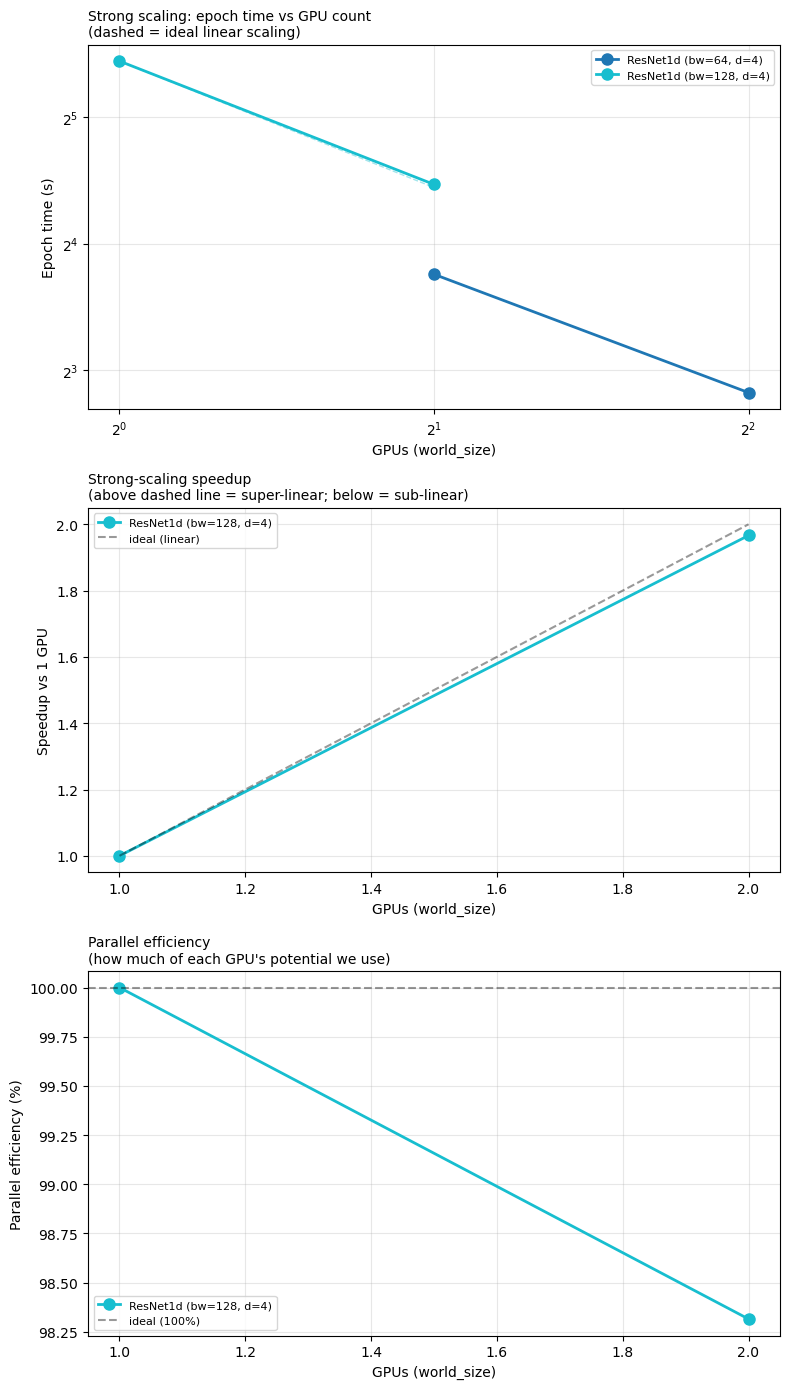

In [4]:
# All three scaling panels stacked
fig = plot_all_scaling(df)